#  💎💰 Predicting Diamond Prices using Linear Regression

**Background:** 

You're a data analyst working at an online jewelry retailer. Thousands of diamonds need to be priced each day, and qualified experts aren't always available to determine the most accurate price. The jewelry retailer is interested in developing a more cost-effective model for diamond pricing. 

They've asked you to predict a reasonable market price for each diamond based on its characteristics like size, cut, and clarity. Then, experts will use your predicted prices as a starting point to finalize pricing more quickly. 

**Task:** Pricing new diamonds acquired by the company, based on:
* Size
* Cut
* Clarity

**Dataset:** Past sales.

<img src="Part2-0.png" width=500>

**Initial Though Process:**

Of course, you know that larger diamonds are more valuable, but by how much? And which matters more, the cut or the clarity?
Your plan is to start with a simple model using just one factor to predict the diamond's price, then add more factors later. 

Neither a confidence interval nor a hypothesis test would be appropriate for this task. You need to predict new prices for individual diamonds, not just perform inference on some characteristics of all diamonds. 

**Linear regression** enables you to quantify relationships in your data, working best for relationships that are very linear. And you'll be able to say more than just, bigger diamonds are associated with higher prices. With regression, you can say something like, a one-carat increase corresponds to a $10,000 increase in price. 

<img src="Part2-1.png" width="700">

Linear regression involves two steps, 
- **training**
- **prediction**

1. **Training**:
 
   Analyzing your existing data to quantify the relationship between two features, like carat and price.

   You're looking to create a line that models the relationship, using the form `y = mx + b`.

   It's called **slope-intercept form**.

   `m` and `b` are called **coefficients**.

    The statistics behind linear regression will take your data set and determine the values for m and b that best fit the data. For example, you may be looking for the equation price equals m times carat plus b. This equation quantifies the relationship between price and carat. Say you run your linear regression and find that the equation that best fits the data is price equals 10,000 times carat plus 2,000. Now you've built your model. 

2. **Prediction**:

   Using this trained model to predict y based on the input x, which in this case means predicting price based on the input carat.

   Imagine you've just received a new diamond, and it's your job to give it an appropriate price based on its carat. If you know the diamond is 0.5 carats, you can plug that into your equation, giving you a final price of $7,000.

**Linear regression** might sound a lot like **correlation**, which also quantifies the relationship between two features. They are indeed related techniques. However, correlation can only quantify the strength and direction of the relationship. 

<img src="Part2-2.png" width=700>

In linear regression terms, both features and outcomes are typically called **variables**. 

Variable is essentially just another term for feature. 

* The **independent variable** corresponds with your **input**. It's the **feature** you think is **causing part of the outcome** and is graphed on the **x-axis**. In this example, it's the carat. 

* The **dependent variable** is the **outcome you're trying to predict**. Here, it's the price of the diamond. 

And the value of price is dependent on carat, the independent variable. When you're trying to determine which variable is which in your data, think about cause and effect.

<img src="Part2-3.png" width=700>

<img src="Part2-4.png" width=700>

### 📊 Step-1: 
First step is to identify the **dependent variable** with in our case is the `Price`.


### 📊 Step-2: 
Next step is to identify the **best independent variable** with which to build your simple linear regression model. 

You'll need to examine **correlations and scatterplots** to achieve this goal.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [4]:
df = pd.read_csv("diamonds.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53941 entries, 0 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53941 non-null  float64
 1   cut      53941 non-null  object 
 2   color    53941 non-null  object 
 3   clarity  53941 non-null  object 
 4   depth    53941 non-null  float64
 5   table    53941 non-null  float64
 6   price    53941 non-null  int64  
 7   x        53941 non-null  float64
 8   y        53941 non-null  float64
 9   z        53941 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [12]:
# identify the numeric columns in the data
columns=["carat", "depth", "table", "x", "y", "z", "price"] # keep price is in the last row of the scatterplots

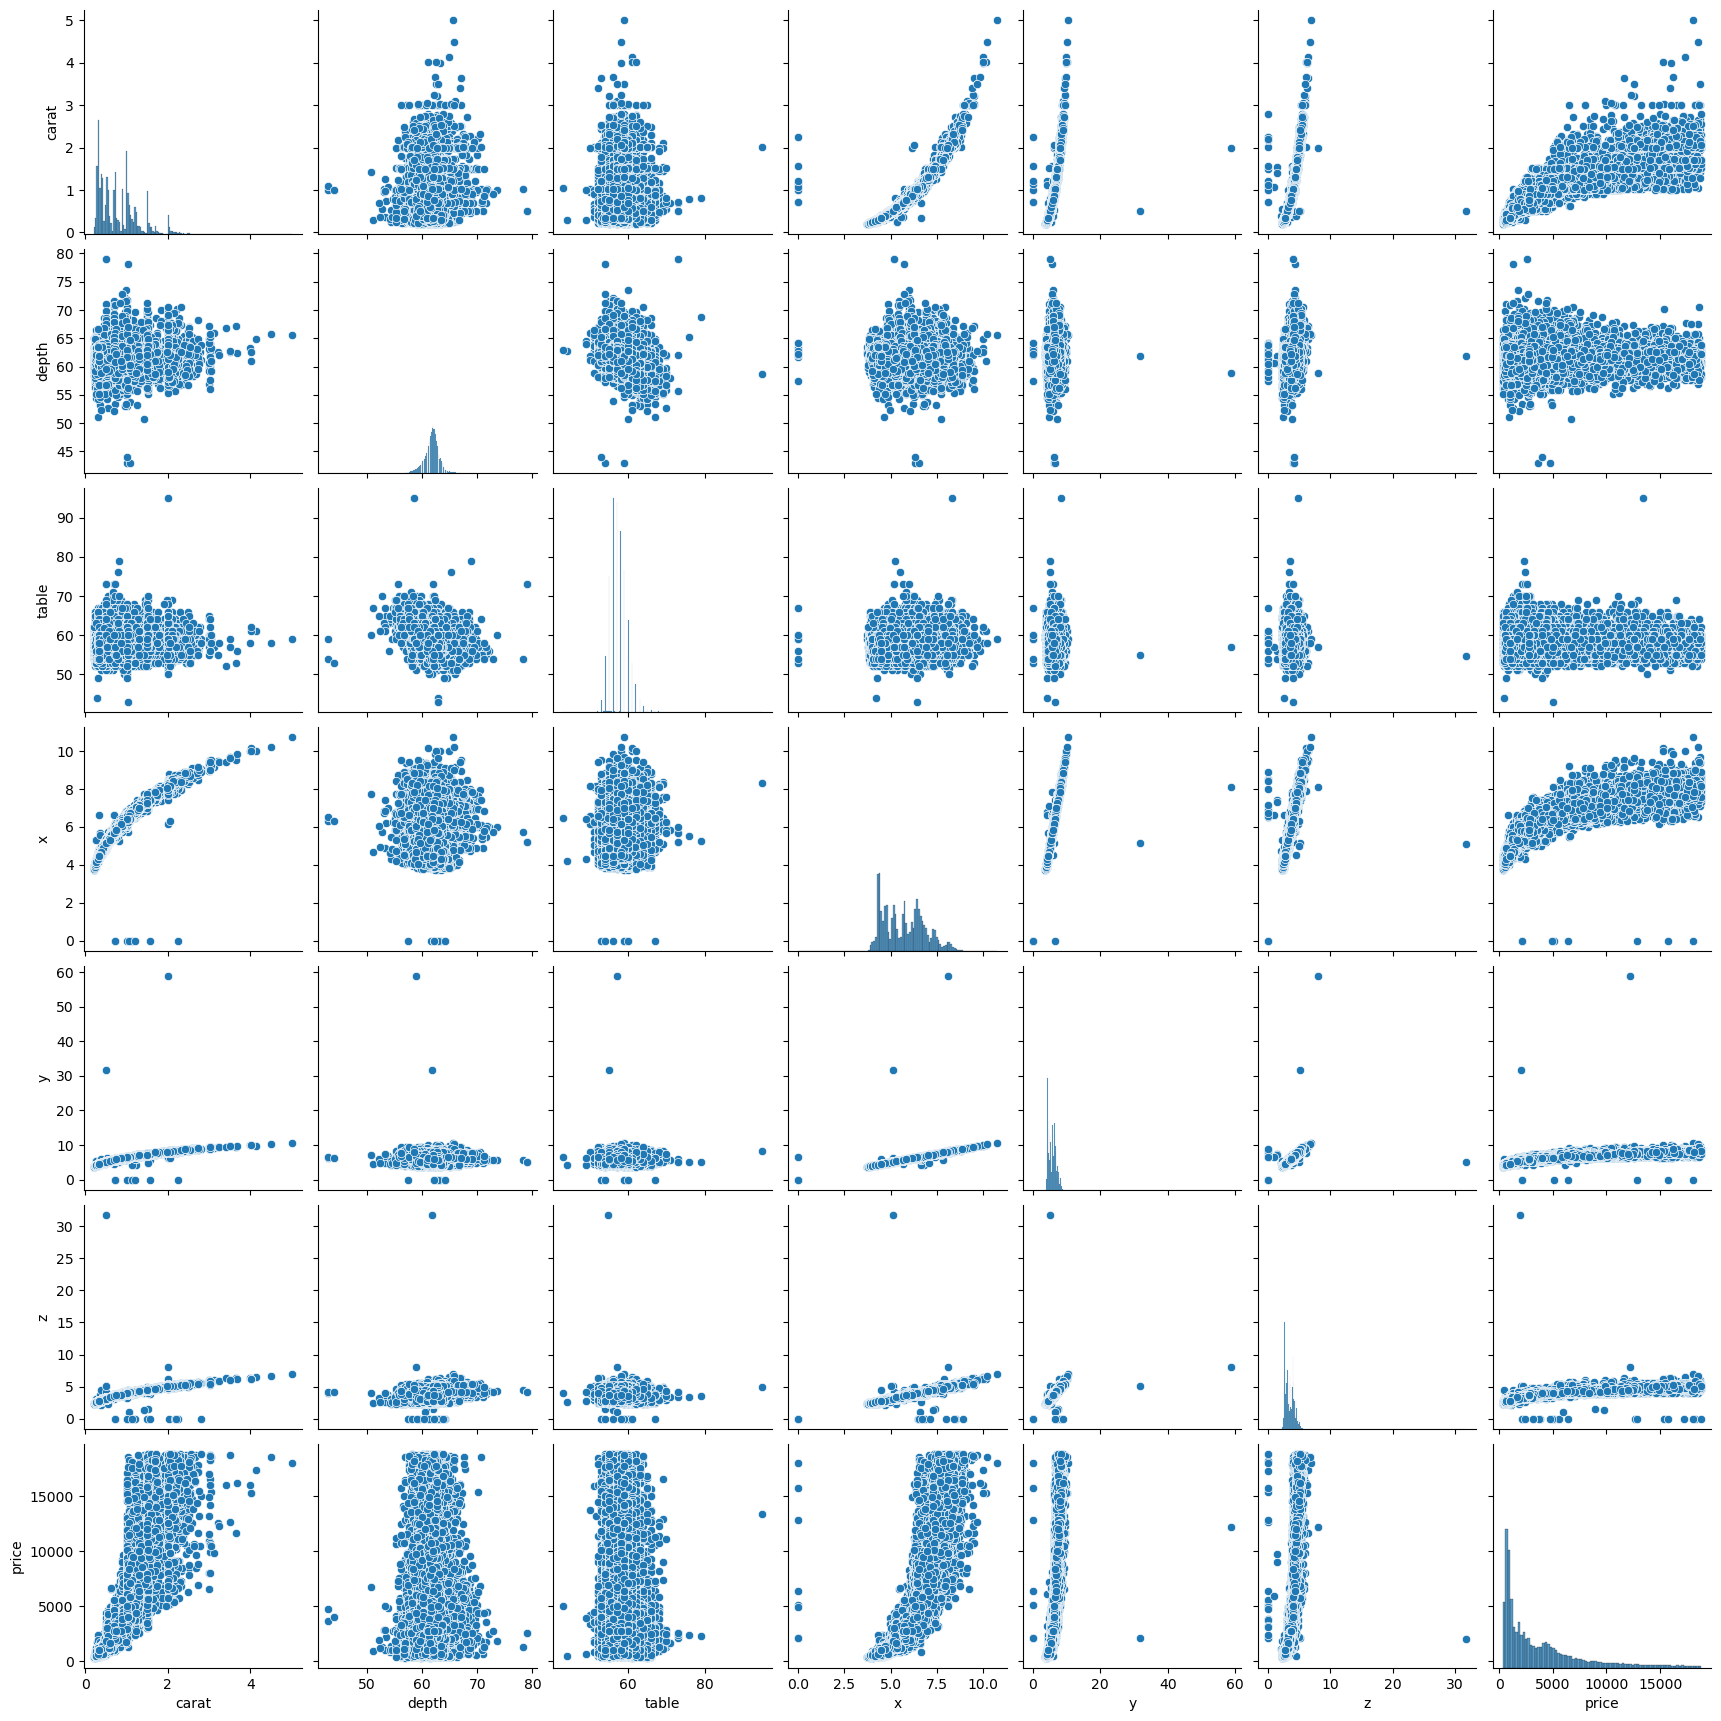

In [13]:
# we create pairplots on these numeric columns
sns.pairplot(df[columns])

`Depth` and `table` don't seem to have much of a noticeable relationship with price. A line through each scatterplot is relatively vertical, but `price` seems to increase as each of `carat`, `x`, `y`, and `z` increases. They may be good candidates for independent variables, but which one is best? 

We use `df[columns].corr()` to **quantify the strength of these relationships**, or in other words, the **predictive power of each independent variable.**

In [14]:
df[columns].corr()

,carat,depth,table,x,y,z,price
carat,1.000000,0.028266,0.181643,0.975095,0.951724,0.953389,0.921593
depth,0.028266,1.000000,-0.295735,-0.025252,-0.029301,0.094964,-0.010613
table,0.181643,-0.295735,1.000000,0.195365,0.183783,0.150955,0.127155
x,0.975095,-0.025252,0.195365,1.000000,0.974702,0.970772,0.884438
y,0.951724,-0.029301,0.183783,0.974702,1.000000,0.952007,0.865425
z,0.953389,0.094964,0.150955,0.970772,0.952007,1.000000,0.861253
price,0.921593,-0.010613,0.127155,0.884438,0.865425,0.861253,1.000000


While x, y, and z are strongly correlated with price, **carat is the most strongly correlated of all these options.**

One way of interpreting correlation here is to say that **"a diamond's carat predicts about 92% of the variability in its price."**

### 📊 Step-3: 
Picking one **independent variable** to develop the first simple linear regression model. 

We have selected **Carat**, as our first independent variable since it has the strongest correlation with our dependent variable, **Price** .

We generate a **scatterplot** of carat and price to examine this relationship in more detail. 

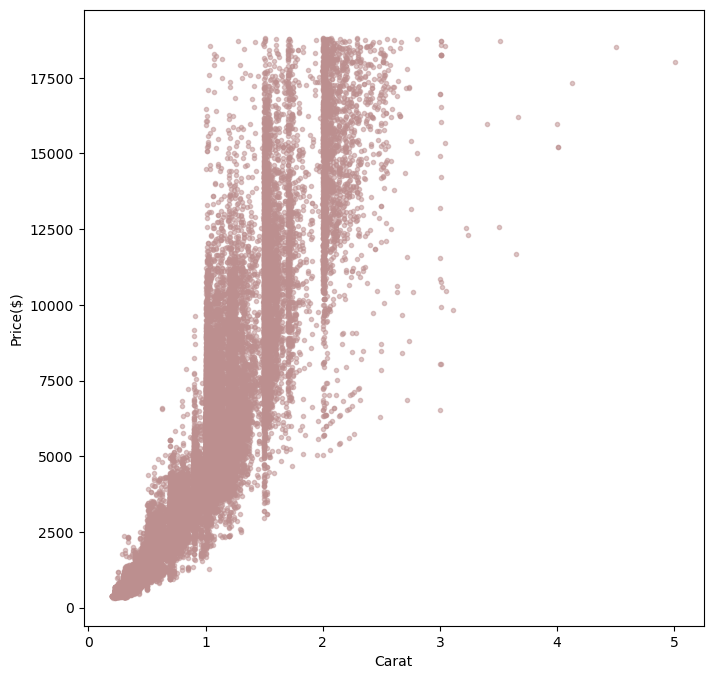

In [17]:
plt.figure(figsize=(8,8))
plt.scatter(df["carat"], df["price"], color="RosyBrown", alpha=0.5, marker=".")
plt.xlabel("Carat")
plt.ylabel("Price($)")
plt.show()

Well, the relationship is quite nonlinear actually. Even though this relationship is nonlinear, you can still use linear regression to model this data fairly accurately. After all, the linear correlation between these two features is quite strong. 

**Summary:**

We used both **visual**(pair plot or heatmaps) and **statistical**(correlation table) methods to identify the most promising independent variables. 

They helped us assess which independent variable would best explain changes in the dependent variable.

### 📊 Step-4: **Training**
Now we will be **training our model**.


<img src="Part2-5.png" width=700>

Notice that your model has two terms, m and b, even though you're only using one independent variable. The point of b is to give your model more flexibility. 

For example, take a look at this data. How would you draw the line of best fit through this data? You might draw the gray line. Now imagine if this line had to go through the origin at (0,0), which would be equivalent to a line of best fit with no intercept, or b equals 0. You would you draw the red line. Well, that certainly isn't a great model for this data, as it would not accurately predict y for most values of x. 

If you don't include the intercept term b, you're basically telling your model that the intercept is 0. Keeping b at 0 limits the flexibility of your model to best fit your data.

In [20]:
# To start training our linear regression model, wefirst import `statsmodels.api`
import statsmodels.api as sm

***Y** is straightforward, use `df["price"]`.*

*For **X**, start with your independent variable, `df["carat"]`. You'll need a bit more than that though, specifically in order to model your intercept.* 

`statsmodels` works by developing a **coefficient for each column** in your x data frame. 

* You want to find two coefficients, `m` and `b`. 
m corresponds with the carat column, but what does b correspond with? 

* Right now, since there's only one column in the x data frame, StatsModels will ignore b and simply set it to zero. That rarely leads to the most accurate model. 

* In order to make sure StatsModels identifies both coefficients, m and b, you'll need to use the `sm.add_constant` function. 

* If you're training a linear regression model, of course you want both m and b. You're just trying to get your data into the right format that StatsModels expects.

In [24]:
# We set up our x and y variables, y for the dependent variable price, and x for the independent variable carat 
Y = df["price"]
X = sm.add_constant(df["carat"])

*Now that you've added this constant column, take a look at the resulting **data frame** `X`. You have a column for the constant, which is the same for all rows, and a column for carat.*

In [23]:
X

,const,carat
0,1.0,0.23
1,1.0,0.21
2,1.0,0.23
3,1.0,0.29
4,1.0,0.31
...,...,...
53936,1.0,0.72
53937,1.0,0.72
53938,1.0,0.70
53939,1.0,0.86


*Meanwhile, `Y` is a **series** containing only the price.*

In [25]:
Y

0         326
1         326
2         327
3         334
4         335
         ... 
53936    2757
53937    2757
53938    2757
53939    2757
53940    2757
Name: price, Length: 53941, dtype: int64

To **train** the regression model, you'll use `sm.OLS`, which stands for **ordinary least squares**. 

It's a foundational type of regression model. 

For the arguments, use y and x. You must start with y. **Regression is not symmetric**, unlike correlation.

In [29]:
model = sm.OLS(Y, X)  # must start with Y
results = model.fit()   # training the model

In [33]:
type(results)

statsmodels.regression.linear_model.RegressionResultsWrapper

In [31]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:34:20   Log-Likelihood:            -4.7274e+05
No. Observations:               53941   AIC:                         9.455e+05
Df Residuals:                   53939   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3385     13.055   -172.831      0.0

<img src="Part2-6.png" width=500>

## Interpreting the output of the regression model

We look out for the following:

- First, the r-squared value. 
- Second, the p-value for the coefficients, both constant and carat. 
- And last, the values of the coefficients themselves.

<img src="Part2-7.png" width=700>

<img src="Part2-8.png" width=700>

<img src="Part2-9.png" width=700>

In [36]:
# Taking an LLM's help for interpretation

<img src="Part2-10.png" width=600>

### 📊 Step-5: **Prediction**

The model coefficients can be used to create the equation of line of best fit. 

`y = mx + b`, or `price = m*carat + b`. 

The coefficients are stored in `results.params`, which stands for parameters. 

In [38]:
results.params  # coefficients

const   -2256.338481
carat    7756.379377
dtype: float64

In [39]:
type(results.params)

pandas.core.series.Series

*Since its a series, we can access these values using the index.*

In [44]:
m = results.params["carat"]
b = results.params["const"]

In [45]:
# We can predict the price for any given carat of diamond now,
carat = 1.5
price = m*carat + b

In [46]:
print(price)

9378.230584795387


In [47]:
# Generate new possible diamonds
# Simulation: using random samples from uniform distribution
carats = np.random.uniform(low=0, high=5, size=20)

In [48]:
print(carats)  # gives a sequence of 20 values

[1.64299402 3.95186445 2.47897798 2.31312453 2.25016282 0.10946274
 1.37808285 2.36925561 4.88910128 3.90752067 2.01276881 1.97658595
 4.50799596 4.5847086  1.59041232 4.0342373  1.91224345 1.50355252
 0.45254106 4.52756952]


In [49]:
type(carats)

numpy.ndarray

In [50]:
# Applying the same equation to carats rather than carat, and saving the result in prices
prices = m*carats + b
prices

array([10487.34641563, 28395.82144289, 16971.55517484, 15685.1329504 ,
       15196.77800547, -1407.30393717,  8432.59495035, 16120.5068719 ,
       35665.38583383, 28051.87424672, 13355.46004108, 13074.81198755,
       32709.38843756, 33304.40072367, 10079.50287259, 29034.73655374,
       12575.74714711,  9405.78527168,  1253.74168602, 32861.20836283])

*This is the estimated prices for each diamond.*

This second price of 28396 corresponds with a diamond with 3.95 carats. That makes sense since a 3.95 carat diamond is quite large. Notice this negative value of around 1400. Well, a diamond can't have a negative price. This is a prediction for a diamond with 0.11 carats. That's quite a small one. 


<img src="Part2-11.png" width=500>

Looking back at the line of best fit, you may notice that the majority of your data is between 0.5 and 2.5 carats. This also seems to be the region of data that your model predicts best. 

Since you know the model's limitations, 
* You can adjust your simulation to only simulate diamonds between 0.5 and 2.5 carats.
* That way, you're using the range where the model performs best. 

Now that you've built a linear regression model with a high R-squared and known limitations, you can take it back to your client. They can use it as a starting point to estimate prices, ​speeding up the process for experts by giving them a general figure to start from. 